## FoodCNN — CNN Training Phase 1: Feature Extraction

Freeze the ResNet-50 backbone and train **only the projection head** (2048→512→101).
This is fast and avoids destroying pretrained features before the backbone is ready to fine-tune.


#### Imports

In [1]:
import os
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image


In [2]:
# mount drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Config

In [3]:
BASE_PATH   = "/content/drive/MyDrive/FoodCNN_dataset/food-101"
BATCH_SIZE  = 64
NUM_EPOCHS  = 5       # phase 1 is short — backbone is frozen
LR          = 1e-3
NUM_WORKERS = 4
CKPT_DIR = "/content/drive/MyDrive/foodcnn_checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


#### Dataset & Transforms

In [4]:
class Food101Dataset(Dataset):
    def __init__(self, base_path, split_file, transform=None):
        self.image_path = os.path.join(base_path, "images")
        self.transform  = transform
        with open(os.path.join(base_path, "meta", split_file)) as f:
            lines = f.read().splitlines()
        self.image_paths = [os.path.join(self.image_path, l + ".jpg") for l in lines]
        raw_labels       = [l.split("/")[0] for l in lines]
        self.classes     = sorted(set(raw_labels))
        c2i              = {c: i for i, c in enumerate(self.classes)}
        self.labels      = [c2i[l] for l in raw_labels]

    def __len__(self):  return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]


In [5]:
# Training transform — augmentation applied only to train split
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Val / test transform — deterministic, no augmentation
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


In [6]:
train_full = Food101Dataset(BASE_PATH, "train.txt" , transform=None)
train_size = int(0.8 * len(train_full))
val_size   = len(train_full) - train_size

train_subset, val_subset_raw = torch.utils.data.random_split(train_full, [train_size, val_size])

# Re-wrap val split with val_transform (no augmentation)
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img_path = self.subset.dataset.image_paths[self.subset.indices[idx]]
        label    = self.subset.dataset.labels[self.subset.indices[idx]]
        img = Image.open(img_path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

train_subset = TransformSubset(train_subset, train_transform)
val_dataset  = TransformSubset(val_subset_raw, val_transform)
test_dataset = Food101Dataset(BASE_PATH, "test.txt", val_transform)

train_loader = DataLoader(train_subset,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {len(train_subset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")


Train: 60600  Val: 15150  Test: 25250


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


#### Model — Frozen Backbone (Phase 1)

All ResNet-50 layers are **frozen**. Only the projection head (fc) is trained.
This is equivalent to using the CNN as a fixed feature extractor.


In [7]:
backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# Freeze all backbone parameters
for param in backbone.parameters():
    param.requires_grad = False

# Replace fc: 2048 -> 512 (visual embed) -> 101 (classes)
backbone.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 101),
)
# fc parameters are trainable by default (newly created)

backbone = backbone.to(device)

trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
total     = sum(p.numel() for p in backbone.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")


Trainable params: 1,100,901 / 24,608,933


#### Training Loop — Phase 1

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(backbone.fc.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_val_acc = 0.0
history      = {"train_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    backbone.train()
    total_loss  = 0.0
    num_batches = len(train_loader)

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(backbone(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if (batch_idx + 1) % 100 == 0:
            print(f"  [{epoch+1}/{NUM_EPOCHS}] batch {batch_idx+1}/{num_batches}"
                  f"  loss={loss.item():.4f}")

    scheduler.step()

    # Validation
    backbone.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            _, preds = torch.max(backbone(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    val_acc  = correct / total
    avg_loss = total_loss / num_batches
    history["train_loss"].append(avg_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  loss={avg_loss:.4f}  val_acc={val_acc:.4f}"
          f"  lr={scheduler.get_last_lr()[0]:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch":           epoch + 1,
            "model_state":     backbone.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc":         val_acc,
        }, os.path.join(CKPT_DIR, "phase1_best.pth"))
        print(f"  -> Saved phase1_best.pth (val_acc={val_acc:.4f})")

print(f"Phase 1 complete. Best val acc: {best_val_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  [1/5] batch 100/947  loss=4.1503
  [1/5] batch 200/947  loss=3.7333
  [1/5] batch 300/947  loss=3.4391
  [1/5] batch 400/947  loss=3.5761
  [1/5] batch 500/947  loss=3.1022
  [1/5] batch 600/947  loss=3.1314
  [1/5] batch 700/947  loss=2.8933
  [1/5] batch 800/947  loss=2.7787
  [1/5] batch 900/947  loss=3.1544
Epoch [1/5]  loss=3.5170  val_acc=0.4101  lr=0.000905
  -> Saved phase1_best.pth (val_acc=0.4101)
  [2/5] batch 100/947  loss=3.2025
  [2/5] batch 200/947  loss=2.8483
  [2/5] batch 300/947  loss=2.7860
  [2/5] batch 400/947  loss=3.1089
  [2/5] batch 500/947  loss=3.0375
  [2/5] batch 600/947  loss=3.2487
  [2/5] batch 700/947  loss=2.9709
  [2/5] batch 800/947  loss=3.1401
  [2/5] batch 900/947  loss=2.8537
Epoch [2/5]  loss=3.0150  val_acc=0.4451  lr=0.000655
  -> Saved phase1_best.pth (val_acc=0.4451)
  [3/5] batch 100/947  loss=2.9558
  [3/5] batch 200/947  loss=3.0778
  [3/5] batch 300/947  loss=2.9314
  [3/5] batch 400/947  loss=3.1779
  [3/5] batch 500/947  loss=2.4849

#### Evaluation & Training Curve

Loaded phase1_best.pth  epoch=5  val_acc=0.4955
Phase 1 Test Accuracy: 0.5339


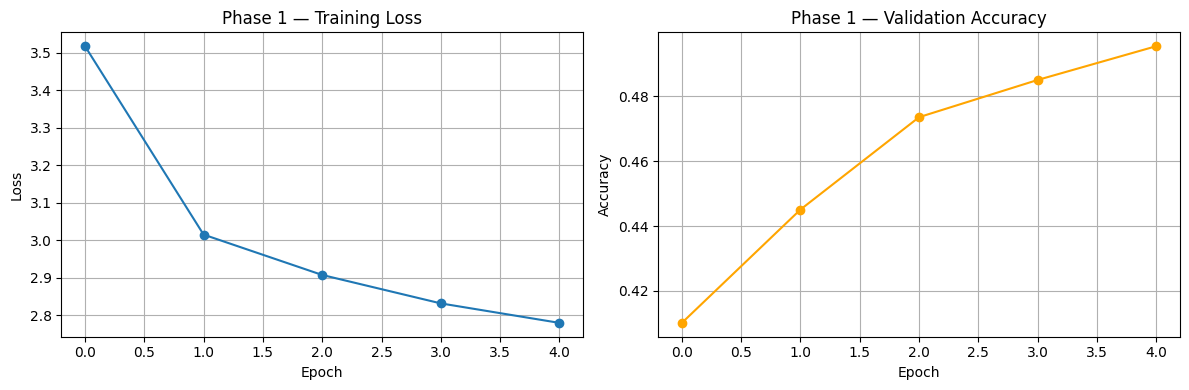

Saved phase1_curve.png


In [9]:
# Load best phase-1 checkpoint
ckpt = torch.load(os.path.join(CKPT_DIR, "phase1_best.pth"), map_location=device)
backbone.load_state_dict(ckpt["model_state"])
print(f"Loaded phase1_best.pth  epoch={ckpt['epoch']}  val_acc={ckpt['val_acc']:.4f}")

# Test accuracy
backbone.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, preds = torch.max(backbone(images), 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
print(f"Phase 1 Test Accuracy: {correct/total:.4f}")

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], marker="o")
axes[0].set_title("Phase 1 — Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].grid(True)
axes[1].plot(history["val_acc"], marker="o", color="orange")
axes[1].set_title("Phase 1 — Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "phase1_curve.png"), dpi=150)
plt.show()
print("Saved phase1_curve.png")
